# GMM Behavioral Regime Detection — C2C Marketplace
**Capstone Project | Author: Arevik Melikyan | Supervisor: Varazdat Stepanyan**

> **Purpose:** Gaussian Mixture Model (GMM) as the **baseline** model for identifying latent behavioral regimes from implicit feedback signals in a C2C marketplace. This notebook covers the full pipeline: data simulation/loading → feature engineering → optimal K selection → GMM fitting → segment profiling → interpretability & visualization.
>
> **Role in thesis:** GMM is the *static* baseline. Unlike HMM, GMM ignores temporal ordering and treats each observation independently. The comparison between GMM and HMM directly addresses Research Question 2: *How do short-term session dynamics compare to long-term preferences?*

---
### Notebook Structure
```
0. Environment & Imports
1. Configuration (single place to change parameters)
2. Data Loading / Simulation
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Preprocessing Pipeline
6. Optimal K Selection (BIC / AIC / Silhouette)
7. Final GMM Fitting
8. Segment Profiling & Interpretation
9. Dimensionality Reduction Visualizations (PCA / UMAP)
10. Stability Validation (bootstrap + repeated runs)
11. Saving Outputs
```

## 0. Environment & Imports

In [12]:
# ── Standard library ────────────────────────────────────────────────────────
import warnings
import os
import json
from pathlib import Path
from datetime import datetime

# ── Core data ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── Optional: UMAP ────────────────────────────────────────────────────────────
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("[INFO] umap-learn not installed. Install: conda install -c conda-forge umap-learn")

# ── Utilities ─────────────────────────────────────────────────────────────────
import joblib
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#4361EE", "#F72585", "#4CC9F0", "#7209B7", "#3A0CA3",
           "#560BAD", "#480CA8", "#B5179E"]
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Dataset path ──────────────────────────────────────────────────────────────
DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/Volumes/T5 EVO"))
DATASET_PATH = DATASET_ROOT / "hf" / "merrec"
assert DATASET_PATH.exists(), f"Not found: {DATASET_PATH}"

print(f"Environment ready | {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Dataset path: {DATASET_PATH}")

Environment ready | 2026-03-21 12:01:49
Dataset path: /Volumes/T5 EVO/hf/merrec


## 1. Configuration
> **Single place to change all parameters.** Never hard-code values elsewhere.

In [13]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
CFG = {
    # ── Data ──────────────────────────────────────────────────────────────────
    "data_path":           str(DATASET_PATH),   # /Volumes/T5 EVO/hf/merrec
    "sample_fraction":     0.00001,                # 1% of each monthly partition
    "positive_action":     "item_view",         # filter to positive events only

    # ── Feature engineering ───────────────────────────────────────────────────
    "session_gap_minutes": 30,
    "features": [
        "session_length",
        "n_unique_items_viewed",
        "revisit_rate",
        "inter_event_time_median",
        "cart_actions",
        "view_depth",
        "session_velocity",
        "category_diversity",
    ],

    # ── Preprocessing ─────────────────────────────────────────────────────────
    "scaler":              "robust",
    "log_transform_cols": [
        "session_length",
        "inter_event_time_median",
        "n_unique_items_viewed",
    ],

    # ── GMM hyperparameter search ─────────────────────────────────────────────
    "k_range":             range(2, 9),
    "covariance_types":    ["full", "tied", "diag", "spherical"],
    "n_init":              10,
    "max_iter":            500,
    "tol":                 1e-4,

    # ── Final model ───────────────────────────────────────────────────────────
    "final_k":             None,     # None = auto-selected via BIC
    "final_cov_type":      "full",

    # ── Stability validation ──────────────────────────────────────────────────
    "bootstrap_n":         30,
    "bootstrap_sample_frac": 0.8,

    # ── Sampling for expensive operations ────────────────────────────────────
    "silhouette_sample_size": 1_000,

    # ── Output ────────────────────────────────────────────────────────────────
    "output_dir":          "gmm_outputs",
}

Path(CFG["output_dir"]).mkdir(parents=True, exist_ok=True)

print("Configuration loaded:")
for k, v in CFG.items():
    print(f"  {k:35s}: {v}")

Configuration loaded:
  data_path                          : /Volumes/T5 EVO/hf/merrec
  sample_fraction                    : 1e-05
  positive_action                    : item_view
  session_gap_minutes                : 30
  features                           : ['session_length', 'n_unique_items_viewed', 'revisit_rate', 'inter_event_time_median', 'cart_actions', 'view_depth', 'session_velocity', 'category_diversity']
  scaler                             : robust
  log_transform_cols                 : ['session_length', 'inter_event_time_median', 'n_unique_items_viewed']
  k_range                            : range(2, 9)
  covariance_types                   : ['full', 'tied', 'diag', 'spherical']
  n_init                             : 10
  max_iter                           : 500
  tol                                : 0.0001
  final_k                            : None
  final_cov_type                     : full
  bootstrap_n                        : 30
  bootstrap_sample_frac           

## 2. Data Loading / Simulation
> **Switch between simulation and real data via `CFG['use_simulation']`.**
>
> Simulation generates a realistic C2C interaction log with 4 hidden behavioral regimes baked in — useful for validating that GMM can recover known structure before running on the real billion-row dataset.

In [ ]:
def simulate_c2c_interactions(
    n_users: int,
    n_sessions: int,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Simulate a C2C interaction log with 4 known behavioral regimes:

    Regime 0 — 'casual browser':     short sessions, low revisit, no cart
    Regime 1 — 'comparison shopper': medium sessions, high revisit, moderate cart
    Regime 2 — 'purchase-intent':    long sessions, high depth, high cart
    Regime 3 — 'cold-start / churn': very short, single visit, no cart

    Returns a session-level DataFrame.
    """
    rng = np.random.default_rng(random_state)

    # Regime mixture weights
    regime_weights = [0.35, 0.30, 0.20, 0.15]
    n_regimes = len(regime_weights)
    regimes_assigned = rng.choice(n_regimes, size=n_sessions, p=regime_weights)

    # Per-regime generative parameters
    # Format: (session_length_mean, session_length_std,
    #          n_items_mean, revisit_rate_mean,
    #          inter_event_mean, cart_mean, view_depth_mean,
    #          velocity_mean, cat_diversity_mean)
    regime_params = {
        0: dict(sess_len=(180, 60),   n_items=(4, 2),   revisit=(0.10, 0.05),
                iet=(120, 60),        cart=(0.2, 0.3),  depth=(2.0, 1.0),
                vel=(0.03, 0.01),     cat_div=(1.2, 0.5)),
        1: dict(sess_len=(600, 150),  n_items=(12, 4),  revisit=(0.45, 0.12),
                iet=(45, 20),         cart=(1.2, 0.8),  depth=(5.0, 1.5),
                vel=(0.07, 0.02),     cat_div=(2.5, 0.8)),
        2: dict(sess_len=(1200, 300), n_items=(20, 6),  revisit=(0.65, 0.15),
                iet=(20, 10),         cart=(3.5, 1.2),  depth=(9.0, 2.5),
                vel=(0.12, 0.03),     cat_div=(1.8, 0.6)),
        3: dict(sess_len=(40, 20),    n_items=(1, 1),   revisit=(0.02, 0.02),
                iet=(600, 200),       cart=(0.0, 0.1),  depth=(1.0, 0.3),
                vel=(0.01, 0.005),    cat_div=(1.0, 0.2)),
    }

    def _sample(mean, std, size, low=0.0):
        """Clipped normal sample."""
        return np.clip(rng.normal(mean, std, size), low, None)

    rows = []
    for regime in range(n_regimes):
        p = regime_params[regime]
        mask = regimes_assigned == regime
        n = mask.sum()
        if n == 0:
            continue
        rows.append(pd.DataFrame({
            "user_id":              rng.integers(0, n_users, n),
            "session_id":           np.where(mask)[0],
            "true_regime":          regime,
            "session_length":       _sample(*p["sess_len"], n, 10),
            "n_unique_items_viewed":np.round(_sample(*p["n_items"], n, 1)).astype(int),
            "revisit_rate":         np.clip(_sample(*p["revisit"], n), 0, 1),
            "inter_event_time_median": _sample(*p["iet"], n, 1),
            "cart_actions":         np.round(_sample(*p["cart"], n, 0)).astype(int),
            "view_depth":           np.round(_sample(*p["depth"], n, 1), 1),
            "session_velocity":     np.clip(_sample(*p["vel"], n), 0.001, None),
            "category_diversity":   np.clip(_sample(*p["cat_div"], n), 1.0, None),
        }))

    df = pd.concat(rows, ignore_index=True).sample(frac=1, random_state=random_state)
    df = df.reset_index(drop=True)
    print(f"Simulated dataset: {len(df):,} sessions | {df['user_id'].nunique():,} users")
    print(f"True regime distribution:\n{df['true_regime'].value_counts().sort_index()}")
    return df


def load_real_data(path: str, sample_fraction: float = 0.01) -> pd.DataFrame:
    """
    Load 1% sample from monthly-partitioned HuggingFace parquet dataset.
    Partitions: 20230501 → 20231001. Filters item_view events only.
    """
    root = Path(path)
    partition_dirs = sorted([
        d for d in root.iterdir()
        if d.is_dir() and d.name.startswith("202")
    ])
    print(f"Found {len(partition_dirs)} partitions: {[d.name for d in partition_dirs]}")

    dfs = []
    for partition in tqdm(partition_dirs, desc="Loading partitions"):
        parquet_files = list(partition.glob("**/*.parquet"))
        if not parquet_files:
            print(f"  [SKIP] No parquet files in {partition.name}")
            continue

        dataset = ds.dataset(parquet_files, format="parquet")
        df_part = dataset.to_table(
            columns=["user_id", "item_id", "event_id", "stime"]
        ).to_pandas()

        # Filter positive actions only
        df_part = df_part[df_part["event_id"] == "item_view"]

        # 1% sample per partition
        n_sample = max(1, int(len(df_part) * sample_fraction))
        df_part = df_part.sample(n=n_sample, random_state=RANDOM_STATE)
        df_part["partition"] = partition.name

        dfs.append(df_part)
        print(f"  [{partition.name}] sampled {len(df_part):,} rows")

    df = pd.concat(dfs, ignore_index=True)
    df = df.rename(columns={"stime": "timestamp"})
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp", "user_id", "item_id"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

    print(f"\nTotal: {len(df):,} rows | {df['user_id'].nunique():,} users | {df['item_id'].nunique():,} items")
    return df




# ── Execute ───────────────────────────────────────────────────────────────────
    df_raw = simulate_c2c_interactions(
        n_users=CFG["n_simulated_users"],
        n_sessions=CFG["n_simulated_sessions"],
        random_state=RANDOM_STATE,
    )
    HAS_TRUE_LABELS = True
else:
    print(f"[MODE] Real data — loading from {CFG['data_path']}")
    df_raw = load_real_data(CFG["data_path"])
    HAS_TRUE_LABELS = "true_regime" in df_raw.columns

df_raw.head(3)

In [16]:
print(list(Path("/Volumes/T5 EVO/hf/merrec").iterdir()))

[PosixPath('/Volumes/T5 EVO/hf/merrec/.cache'), PosixPath('/Volumes/T5 EVO/hf/merrec/20230501'), PosixPath('/Volumes/T5 EVO/hf/merrec/.gitattributes'), PosixPath('/Volumes/T5 EVO/hf/merrec/20230601'), PosixPath('/Volumes/T5 EVO/hf/merrec/20230701'), PosixPath('/Volumes/T5 EVO/hf/merrec/20230801'), PosixPath('/Volumes/T5 EVO/hf/merrec/20230901'), PosixPath('/Volumes/T5 EVO/hf/merrec/20231001')]


## 3. Exploratory Data Analysis

In [17]:
# ── Basic statistics ──────────────────────────────────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape             : {df_raw.shape}")
print(f"Unique users      : {df_raw['user_id'].nunique():,}")
print(f"Sessions per user : {len(df_raw) / df_raw['user_id'].nunique():.1f} avg")
print(f"Missing values    :")
print(df_raw[CFG["features"]].isnull().sum().to_string())

print("\nDescriptive statistics:")
display(df_raw[CFG["features"]].describe().round(2))

DATASET OVERVIEW


NameError: name 'df_raw' is not defined

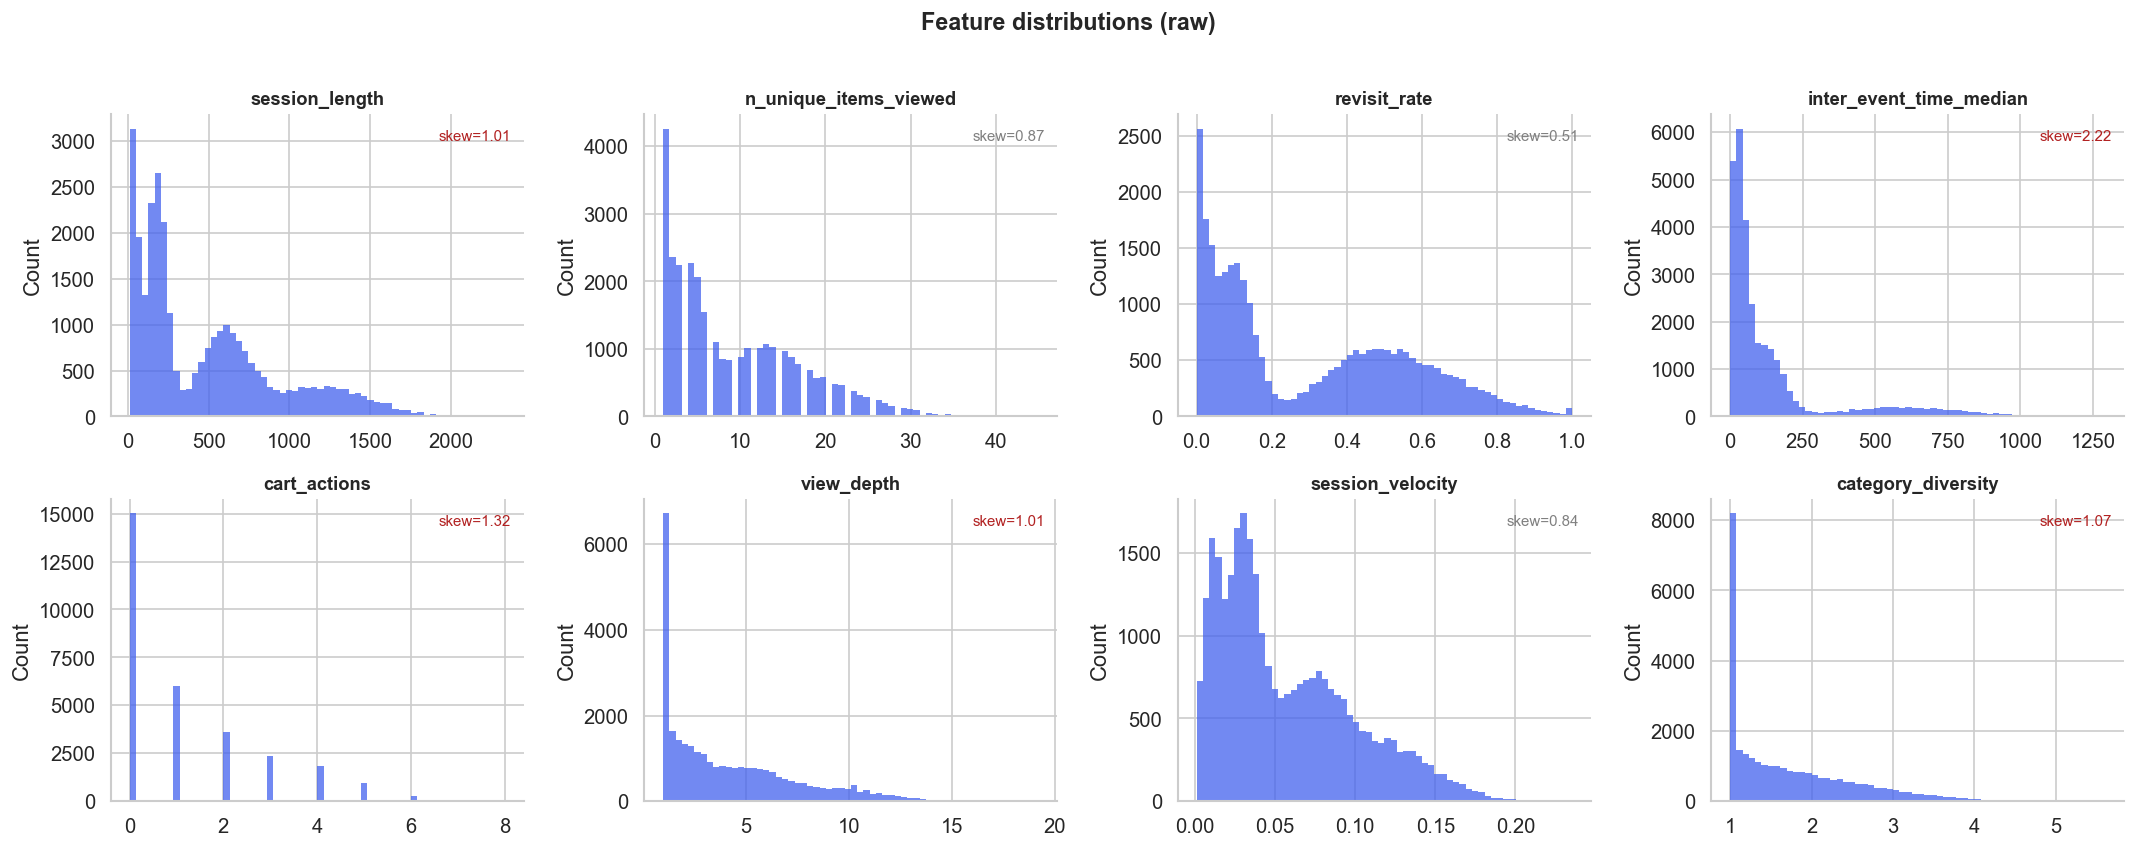

[SAVED] 01_feature_distributions.png


In [ ]:
# ── Feature distributions ─────────────────────────────────────────────────────
n_features = len(CFG["features"])
n_cols = 4
n_rows = -(-n_features // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(CFG["features"]):
    ax = axes[i]
    data = df_raw[feat].dropna()
    ax.hist(data, bins=60, color=PALETTE[0], alpha=0.75, edgecolor="none")
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    # Annotate skewness
    skew = data.skew()
    ax.text(0.97, 0.95, f"skew={skew:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            color="firebrick" if abs(skew) > 1 else "gray")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature distributions (raw)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/01_feature_distributions.png", bbox_inches="tight")
plt.show()
print("[SAVED] 01_feature_distributions.png")

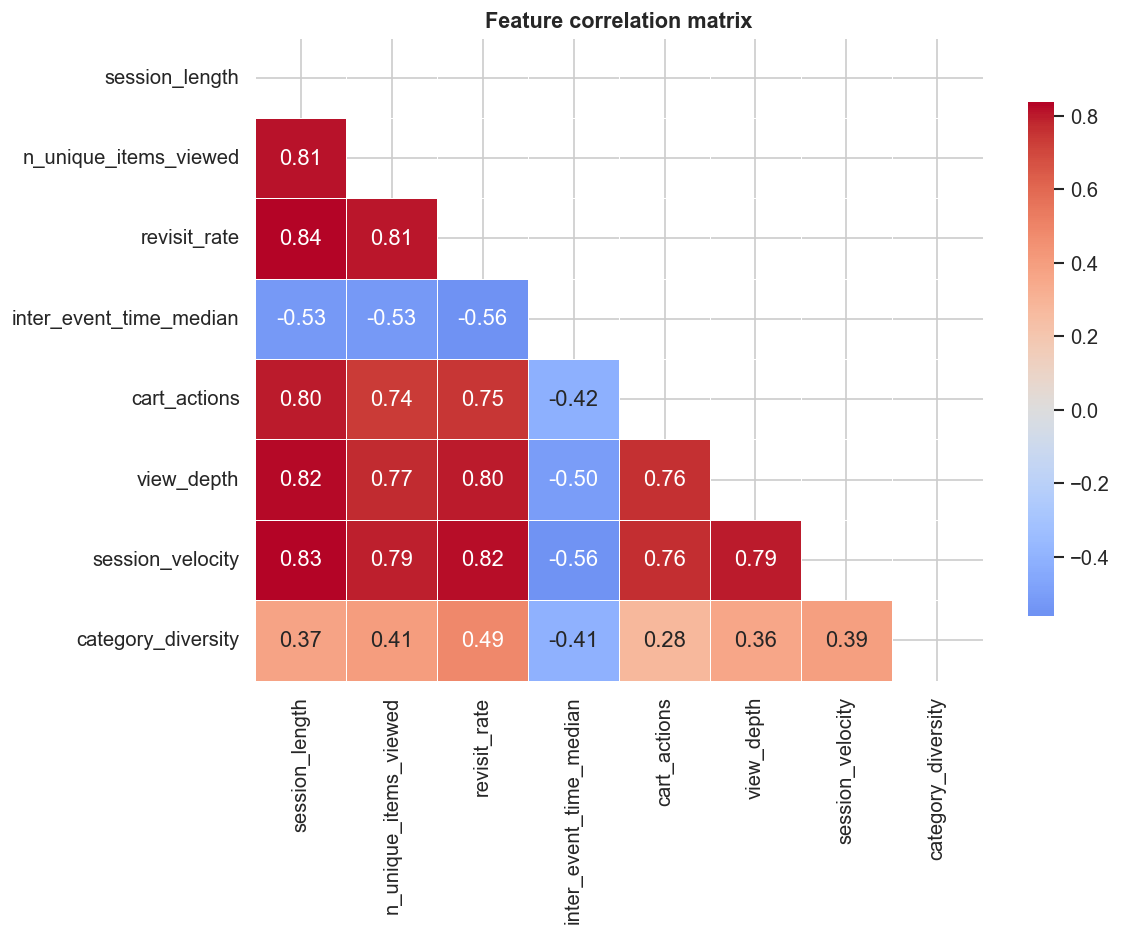

[SAVED] 02_correlation_heatmap.png


In [ ]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_raw[CFG["features"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature correlation matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/02_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("[SAVED] 02_correlation_heatmap.png")

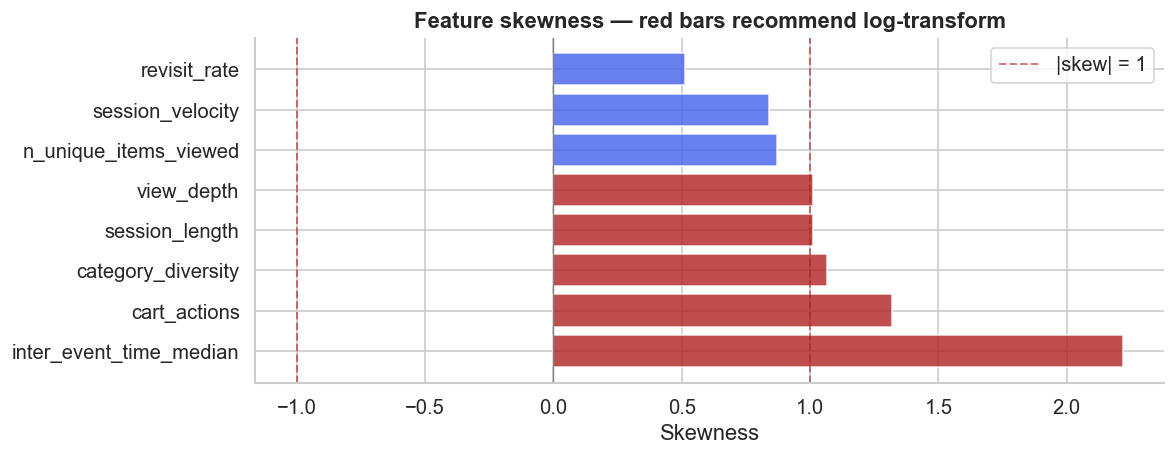

[SAVED] 03_skewness.png


In [ ]:
# ── Long-tail check ───────────────────────────────────────────────────────────
# Log-transform candidates: features with |skewness| > 1
skewness = df_raw[CFG["features"]].skew().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["firebrick" if abs(s) > 1 else PALETTE[0] for s in skewness]
ax.barh(skewness.index, skewness.values, color=colors, alpha=0.8)
ax.axvline(1, color="firebrick", lw=1.2, ls="--", alpha=0.6, label="|skew| = 1")
ax.axvline(-1, color="firebrick", lw=1.2, ls="--", alpha=0.6)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("Skewness")
ax.set_title("Feature skewness — red bars recommend log-transform", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/03_skewness.png", bbox_inches="tight")
plt.show()
print("[SAVED] 03_skewness.png")

## 4. Feature Engineering
> If your raw data is **event-level** (one row per click/view), use the aggregation helpers below to collapse to session-level features. If you already have session-level data, skip to Section 5.

In [ ]:
def engineer_session_features_from_events(events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate an event-level log into session-level behavioral features.

    Expected event_df columns:
        user_id, item_id, timestamp (Unix or datetime), event_type, category_id
        Optional: is_cart (bool), price

    Returns one row per (user_id, session_id) with all behavioral features.
    """
    df = events_df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s") \
        if df["timestamp"].dtype in ["int64", "float64"] \
        else pd.to_datetime(df["timestamp"])

    df = df.sort_values(["user_id", "timestamp"])

    # ── Session boundary: gap > session_gap_minutes ──────────────────────────
    gap_threshold = pd.Timedelta(minutes=CFG["session_gap_minutes"])
    df["time_diff"] = df.groupby("user_id")["timestamp"].diff()
    df["new_session"] = (
        df["time_diff"].isna() | (df["time_diff"] > gap_threshold)
    )
    df["session_id"] = df.groupby("user_id")["new_session"].cumsum()

    # ── Aggregate per session ─────────────────────────────────────────────────
    agg = df.groupby(["user_id", "session_id"]).agg(
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        n_events=("item_id", "count"),
        n_unique_items_viewed=("item_id", "nunique"),
        cart_actions=("is_cart", "sum") if "is_cart" in df.columns
                     else ("item_id", lambda x: 0),
        category_diversity=("category_id", "nunique") if "category_id" in df.columns
                           else ("item_id", lambda x: 1),
    ).reset_index()

    # ── Derived features ──────────────────────────────────────────────────────
    agg["session_length"] = (
        (agg["session_end"] - agg["session_start"]).dt.total_seconds()
    ).clip(lower=1)

    agg["view_depth"] = agg["n_unique_items_viewed"]

    # Velocity: events per second
    agg["session_velocity"] = agg["n_events"] / agg["session_length"]

    # Median inter-event time per session
    iet = (
        df.groupby(["user_id", "session_id"])["time_diff"]
        .apply(lambda x: x.dt.total_seconds().dropna().median())
        .reset_index()
        .rename(columns={"time_diff": "inter_event_time_median"})
    )
    agg = agg.merge(iet, on=["user_id", "session_id"], how="left")

    # Revisit rate: fraction of items revisited (viewed > once) per session
    revisit = (
        df.groupby(["user_id", "session_id", "item_id"])
        .size()
        .reset_index(name="item_count")
        .groupby(["user_id", "session_id"])
        .apply(lambda g: (g["item_count"] > 1).mean())
        .reset_index(name="revisit_rate")
    )
    agg = agg.merge(revisit, on=["user_id", "session_id"], how="left")
    agg["revisit_rate"] = agg["revisit_rate"].fillna(0)

    return agg


# ── For simulated data, features are already at session level ─────────────────
# If you have raw events, do:
#   df_sessions = engineer_session_features_from_events(df_raw)
# For now, df_raw IS the session-level frame:
df_sessions = df_raw.copy()

print(f"Session-level DataFrame: {df_sessions.shape}")
df_sessions[CFG["features"]].head(3)

Session-level DataFrame: (30000, 11)


,session_length,n_unique_items_viewed,revisit_rate,inter_event_time_median,cart_actions,view_depth,session_velocity,category_diversity
0,221.700576,1,0.233630,162.374907,0,2.1,0.034589,1.000000
1,1319.777246,23,0.737375,21.343350,2,8.5,0.087391,1.138610
2,1289.750072,17,0.709578,12.157434,4,5.9,0.142657,1.933432


## 5. Preprocessing Pipeline

Feature matrix shape : (30000, 8)
Mean per feature     : [-0.037 -0.045  0.215  0.055  0.566  0.203  0.221  0.195]
Std  per feature     : [0.744 0.627 0.578 0.785 0.745 0.693 0.694 0.66 ]


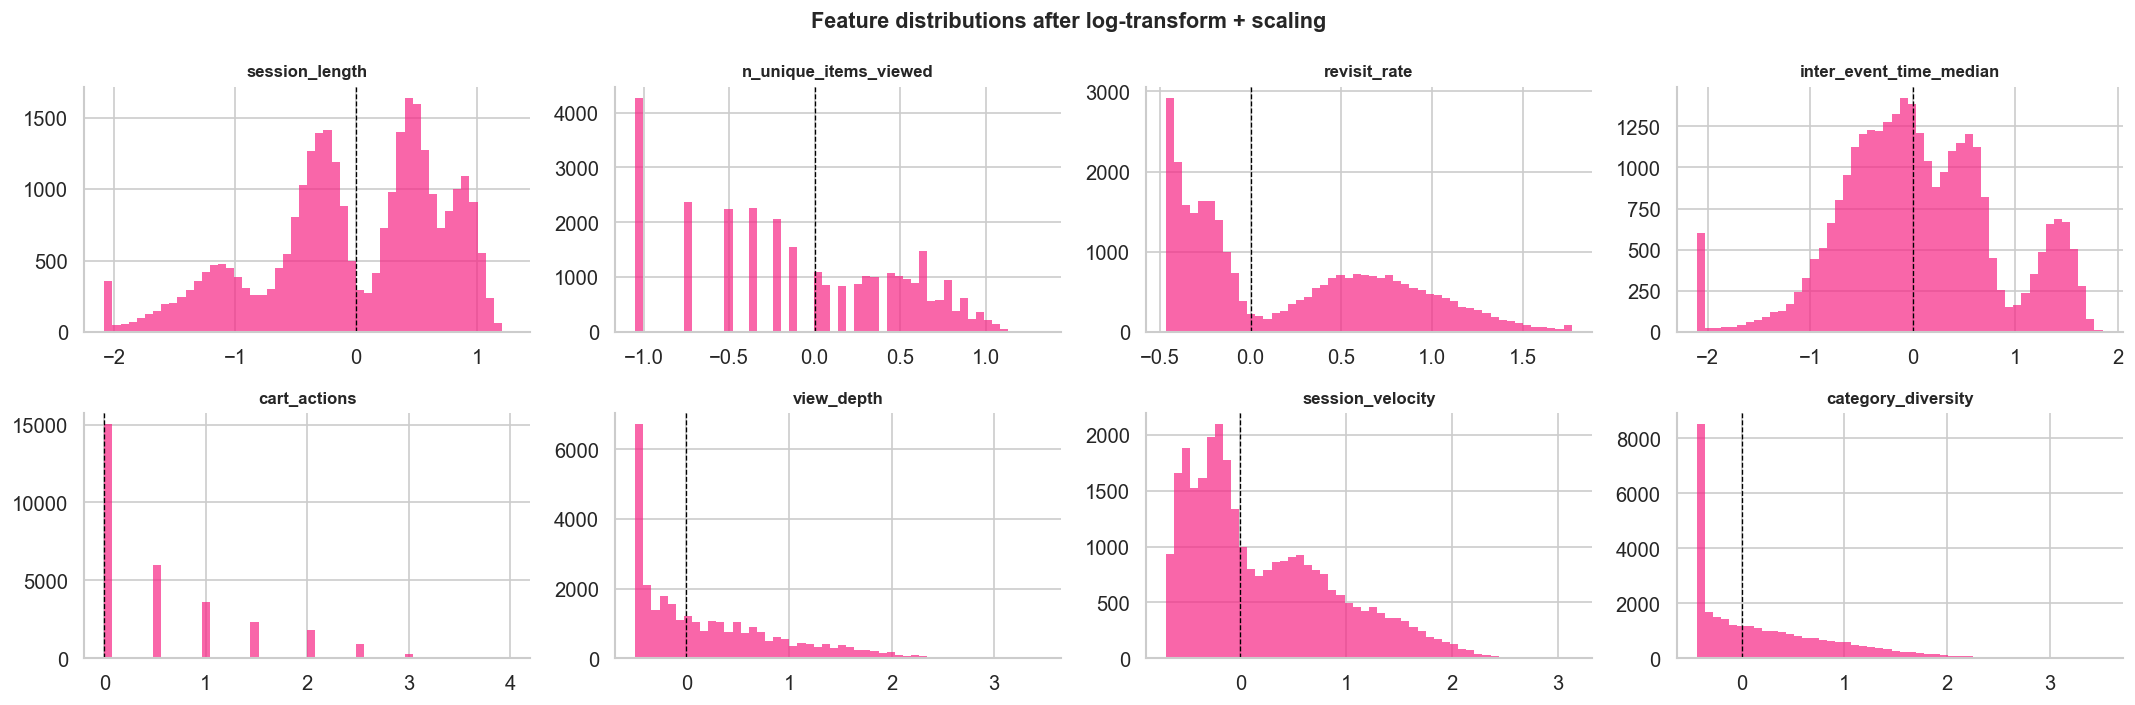

[SAVED] 04_features_scaled.png


In [ ]:
def build_feature_matrix(df: pd.DataFrame, cfg: dict) -> np.ndarray:
    """
    Build a clean, scaled feature matrix ready for GMM.

    Steps:
      1. Select features
      2. Impute missing values (median)
      3. Apply log1p to skewed features
      4. Scale with RobustScaler or StandardScaler

    Returns X (np.ndarray, n_samples × n_features)
    """
    features = cfg["features"]
    X = df[features].copy()

    # ── 1. Impute ─────────────────────────────────────────────────────────────
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=features)

    # ── 2. Log-transform long-tail features ───────────────────────────────────
    for col in cfg["log_transform_cols"]:
        if col in features:
            X[col] = np.log1p(X[col])

    # ── 3. Scale ──────────────────────────────────────────────────────────────
    Scaler = RobustScaler if cfg["scaler"] == "robust" else StandardScaler
    scaler = Scaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler


X, fitted_scaler = build_feature_matrix(df_sessions, CFG)

print(f"Feature matrix shape : {X.shape}")
print(f"Mean per feature     : {X.mean(axis=0).round(3)}")
print(f"Std  per feature     : {X.std(axis=0).round(3)}")

# ── Visualize post-scaling distributions ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for i, (ax, feat) in enumerate(zip(axes.flatten(), CFG["features"])):
    ax.hist(X[:, i], bins=50, color=PALETTE[1], alpha=0.7, edgecolor="none")
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.axvline(0, color="black", lw=0.8, ls="--")
fig.suptitle("Feature distributions after log-transform + scaling", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/04_features_scaled.png", bbox_inches="tight")
plt.show()
print("[SAVED] 04_features_scaled.png")

## 6. Optimal K Selection
> Three complementary criteria: **BIC** (primary, lower = better), **AIC**, and **Silhouette score** (secondary, higher = better). Covariance type search is included.

In [ ]:
def gmm_model_selection(
    X: np.ndarray,
    k_range,
    covariance_types: list,
    n_init: int,
    max_iter: int,
    tol: float,
    silhouette_sample_size: int,
    random_state: int,
) -> pd.DataFrame:
    """
    Grid search over (k, covariance_type) for GMM.

    Metrics collected per configuration:
        - BIC (primary model selection criterion)
        - AIC
        - Log-likelihood
        - Silhouette score (sampled for speed)
        - Davies-Bouldin index (lower = better)
        - Calinski-Harabasz index (higher = better)
        - Converged (bool)

    Returns a DataFrame of all configurations sorted by BIC.
    """
    results = []
    total = len(list(k_range)) * len(covariance_types)
    pbar = tqdm(total=total, desc="Model selection grid search")

    for cov_type in covariance_types:
        for k in k_range:
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=cov_type,
                n_init=n_init,
                max_iter=max_iter,
                tol=tol,
                random_state=random_state,
            )
            gmm.fit(X)
            labels = gmm.predict(X)

            # Silhouette requires at least 2 unique labels
            n_unique = len(np.unique(labels))
            if n_unique < 2:
                sil = np.nan
            else:
                sample_idx = np.random.choice(
                    len(X),
                    min(silhouette_sample_size, len(X)),
                    replace=False
                )
                sil = silhouette_score(X[sample_idx], labels[sample_idx])

            db = davies_bouldin_score(X, labels) if n_unique >= 2 else np.nan
            ch = calinski_harabasz_score(X, labels) if n_unique >= 2 else np.nan

            results.append({
                "k": k,
                "cov_type": cov_type,
                "bic": gmm.bic(X),
                "aic": gmm.aic(X),
                "log_likelihood": gmm.lower_bound_,
                "silhouette": sil,
                "davies_bouldin": db,
                "calinski_harabasz": ch,
                "converged": gmm.converged_,
            })
            pbar.update(1)

    pbar.close()
    results_df = pd.DataFrame(results).sort_values("bic")
    return results_df


print("Running model selection grid search...")
selection_df = gmm_model_selection(
    X=X,
    k_range=CFG["k_range"],
    covariance_types=CFG["covariance_types"],
    n_init=CFG["n_init"],
    max_iter=CFG["max_iter"],
    tol=CFG["tol"],
    silhouette_sample_size=CFG["silhouette_sample_size"],
    random_state=RANDOM_STATE,
)

print("\nTop 10 configurations by BIC:")
display(selection_df.head(10).reset_index(drop=True))
selection_df.to_csv(f"{CFG['output_dir']}/model_selection_results.csv", index=False)
print("[SAVED] model_selection_results.csv")

Running model selection grid search...


Model selection grid search:   0%|          | 0/28 [00:00<?, ?it/s]


Top 10 configurations by BIC:


,k,cov_type,bic,aic,log_likelihood,silhouette,davies_bouldin,calinski_harabasz,converged
0,8,diag,-61023.988356,-62145.696965,1.040197,0.213642,2.344065,16013.264396,True
1,8,full,-59181.457985,-62164.371990,1.047958,0.172991,2.755221,15675.151455,True
2,7,diag,-58816.848063,-59797.304477,1.000507,0.254647,2.003527,18194.374961,True
3,7,full,-57016.178856,-59625.189991,1.004130,0.233932,2.371393,17744.519507,True
4,6,full,-41941.120017,-44176.228283,0.745235,0.294231,2.088339,19427.698444,True
5,5,full,-6205.244666,-8066.450062,0.141885,0.231154,2.065353,17736.922608,True
6,4,full,257.238197,-1230.064330,0.026432,0.269218,1.590713,23441.290869,True
7,6,diag,45116.691899,44277.487680,-0.734635,0.331155,1.850655,21151.935677,True
8,5,diag,52539.417019,51841.464995,-0.861295,0.415630,1.135731,25742.697864,True
9,4,diag,59989.656667,59432.956839,-0.988316,0.410007,0.953115,32120.975952,True


[SAVED] model_selection_results.csv


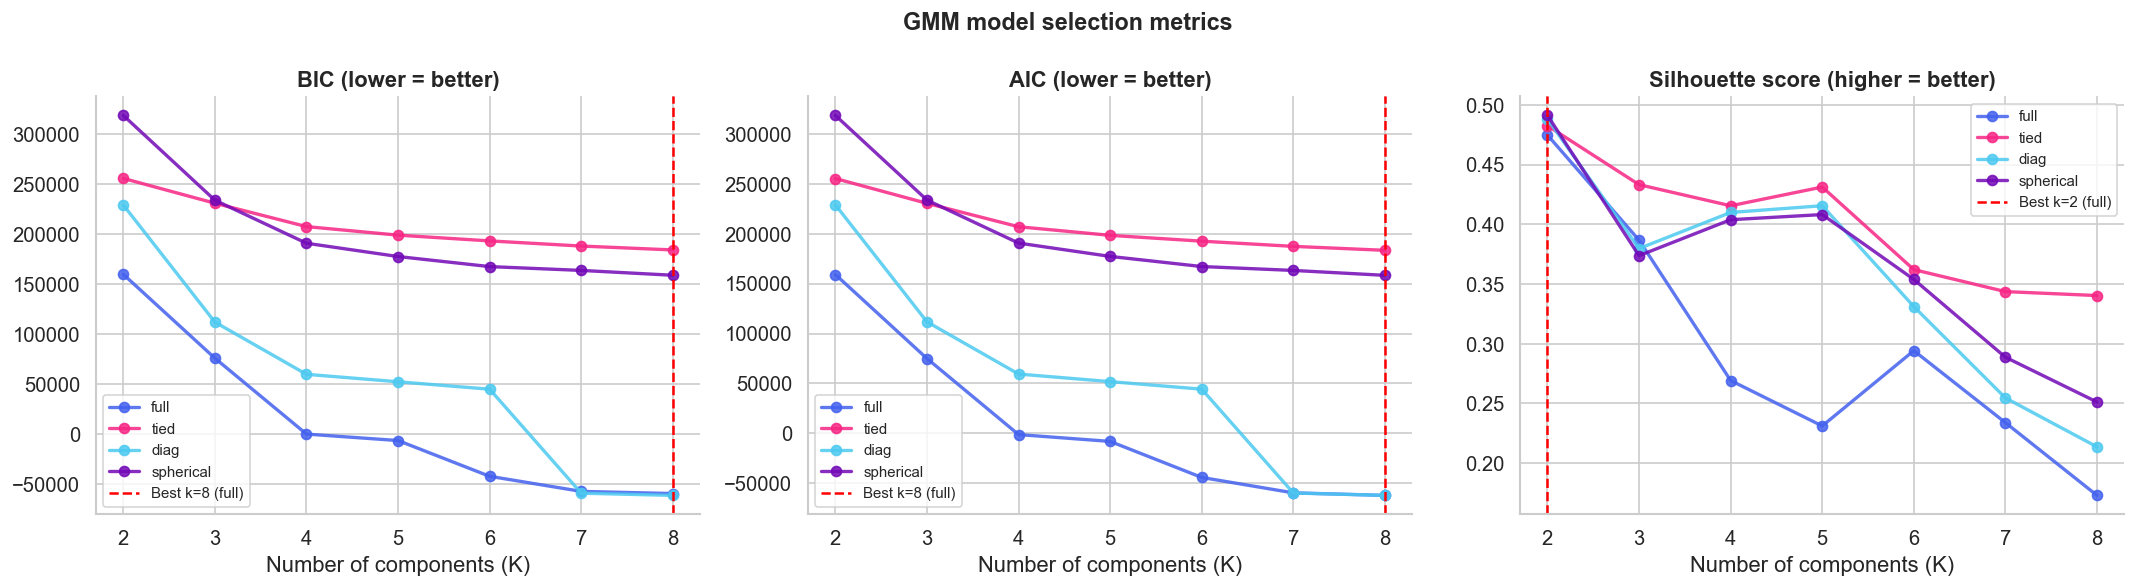

[SAVED] 05_model_selection_curves.png


In [ ]:
# ── Plot BIC / AIC / Silhouette curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("bic", "BIC (lower = better)", True),
    ("aic", "AIC (lower = better)", True),
    ("silhouette", "Silhouette score (higher = better)", False),
]

for ax, (metric, title, lower_better) in zip(axes, metrics):
    for j, cov_type in enumerate(CFG["covariance_types"]):
        sub = selection_df[selection_df["cov_type"] == cov_type].sort_values("k")
        ax.plot(sub["k"], sub[metric], marker="o", lw=2,
                color=PALETTE[j], label=cov_type, alpha=0.85)

    # Mark the best k for the full covariance
    best_row = selection_df[selection_df["cov_type"] == CFG["final_cov_type"]].sort_values(
        metric, ascending=lower_better
    ).iloc[0]
    ax.axvline(best_row["k"], color="red", ls="--", lw=1.5,
               label=f"Best k={int(best_row['k'])} (full)")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Number of components (K)")
    ax.set_xticks(list(CFG["k_range"]))
    ax.legend(fontsize=9)

fig.suptitle("GMM model selection metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/05_model_selection_curves.png", bbox_inches="tight")
plt.show()
print("[SAVED] 05_model_selection_curves.png")

In [ ]:
# ── Auto-select K from BIC (full covariance) ──────────────────────────────────
if CFG["final_k"] is None:
    best = selection_df[
        selection_df["cov_type"] == CFG["final_cov_type"]
    ].sort_values("bic").iloc[0]
    BEST_K = int(best["k"])
    print(f"[AUTO] Best K = {BEST_K} (BIC={best['bic']:.1f}, "
          f"silhouette={best['silhouette']:.3f})")
else:
    BEST_K = CFG["final_k"]
    print(f"[MANUAL] Using K = {BEST_K} as set in CFG['final_k']")

print(f"Final model config: K={BEST_K}, covariance_type='{CFG['final_cov_type']}'")

[AUTO] Best K = 8 (BIC=-59181.5, silhouette=0.173)
Final model config: K=8, covariance_type='full'


## 7. Final GMM Fitting

In [ ]:
# ── Train final model ─────────────────────────────────────────────────────────
print(f"Fitting final GMM: K={BEST_K}, cov_type='{CFG['final_cov_type']}'")

final_gmm = GaussianMixture(
    n_components=BEST_K,
    covariance_type=CFG["final_cov_type"],
    n_init=CFG["n_init"] * 2,   # More restarts for final model
    max_iter=CFG["max_iter"],
    tol=CFG["tol"],
    random_state=RANDOM_STATE,
)
final_gmm.fit(X)

print(f"Converged          : {final_gmm.converged_}")
print(f"Iterations         : {final_gmm.n_iter_}")
print(f"Log-likelihood     : {final_gmm.lower_bound_:.4f}")
print(f"BIC                : {final_gmm.bic(X):.2f}")
print(f"AIC                : {final_gmm.aic(X):.2f}")

# ── Assign labels and posterior probabilities ─────────────────────────────────
hard_labels = final_gmm.predict(X)                   # argmax assignment
soft_probs  = final_gmm.predict_proba(X)             # posterior probabilities

df_sessions["gmm_regime"]    = hard_labels
df_sessions["max_posterior"] = soft_probs.max(axis=1)  # confidence
for k in range(BEST_K):
    df_sessions[f"prob_regime_{k}"] = soft_probs[:, k]

# ── Regime distribution ───────────────────────────────────────────────────────
regime_counts = df_sessions["gmm_regime"].value_counts().sort_index()
print("\nRegime distribution:")
for r, c in regime_counts.items():
    pct = 100 * c / len(df_sessions)
    print(f"  Regime {r}: {c:>8,} sessions ({pct:.1f}%)")

# ── Save model ────────────────────────────────────────────────────────────────
joblib.dump(final_gmm, f"{CFG['output_dir']}/gmm_final_model.pkl")
joblib.dump(fitted_scaler, f"{CFG['output_dir']}/gmm_scaler.pkl")
print("\n[SAVED] gmm_final_model.pkl + gmm_scaler.pkl")

Fitting final GMM: K=8, cov_type='full'
Converged          : True
Iterations         : 32
Log-likelihood     : 1.0480
BIC                : -59181.58
AIC                : -62164.49

Regime distribution:
  Regime 0:    6,484 sessions (21.6%)
  Regime 1:    8,607 sessions (28.7%)
  Regime 2:    4,955 sessions (16.5%)
  Regime 3:      635 sessions (2.1%)
  Regime 4:    2,164 sessions (7.2%)
  Regime 5:    4,418 sessions (14.7%)
  Regime 6:    1,562 sessions (5.2%)
  Regime 7:    1,175 sessions (3.9%)

[SAVED] gmm_final_model.pkl + gmm_scaler.pkl


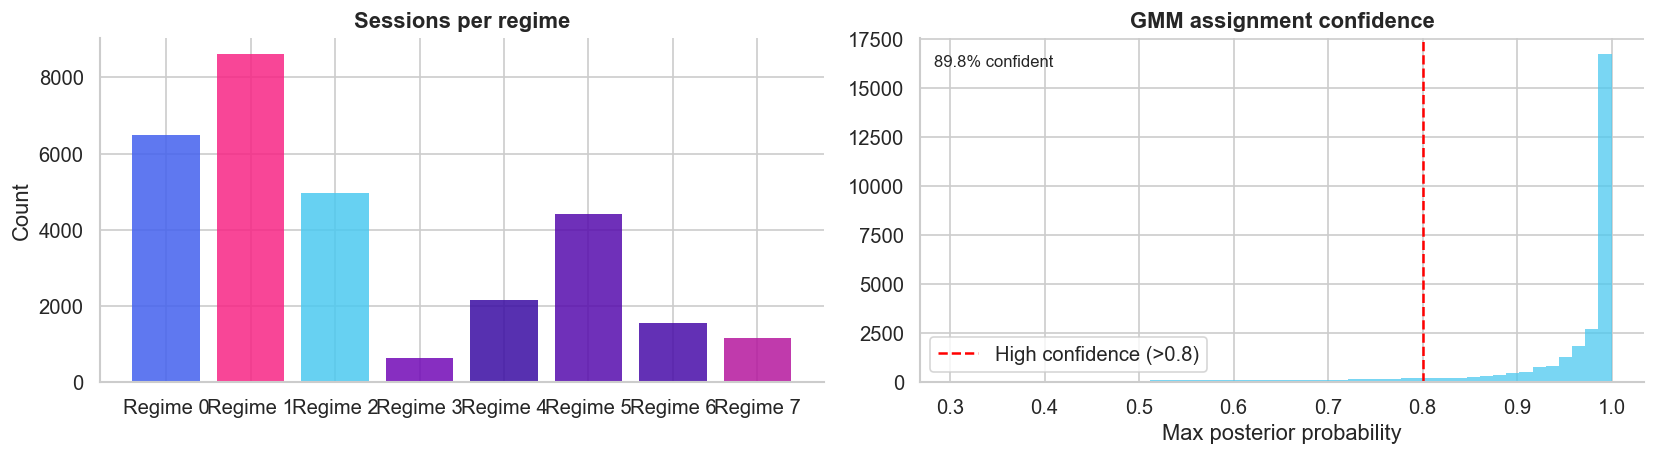

[SAVED] 06_regime_distribution.png


In [ ]:
# ── Posterior confidence distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Regime size
axes[0].bar(
    [f"Regime {r}" for r in regime_counts.index],
    regime_counts.values,
    color=PALETTE[:len(regime_counts)], alpha=0.85, edgecolor="none"
)
axes[0].set_title("Sessions per regime", fontweight="bold")
axes[0].set_ylabel("Count")

# Confidence distribution
axes[1].hist(
    df_sessions["max_posterior"], bins=50,
    color=PALETTE[2], alpha=0.75, edgecolor="none"
)
axes[1].axvline(0.8, color="red", ls="--", lw=1.5, label="High confidence (>0.8)")
axes[1].set_xlabel("Max posterior probability")
axes[1].set_title("GMM assignment confidence", fontweight="bold")
axes[1].legend()
pct_confident = (df_sessions["max_posterior"] > 0.8).mean() * 100
axes[1].text(0.02, 0.95, f"{pct_confident:.1f}% confident",
             transform=axes[1].transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/06_regime_distribution.png", bbox_inches="tight")
plt.show()
print("[SAVED] 06_regime_distribution.png")

## 8. Segment Profiling & Interpretation
> The most important section for your capstone — understand *what* each regime means behaviorally.

In [ ]:
# ── Per-regime mean feature profiles ─────────────────────────────────────────
profile_raw = df_sessions.groupby("gmm_regime")[CFG["features"]].mean()
profile_raw["n_sessions"] = df_sessions.groupby("gmm_regime").size()
profile_raw["pct"] = profile_raw["n_sessions"] / len(df_sessions) * 100

print("Regime mean feature profiles (original scale):")
display(profile_raw.round(3))
profile_raw.to_csv(f"{CFG['output_dir']}/regime_profiles.csv")
print("[SAVED] regime_profiles.csv")

Regime mean feature profiles (original scale):


,session_length,n_unique_items_viewed,revisit_rate,inter_event_time_median,cart_actions,view_depth,session_velocity,category_diversity,n_sessions,pct
gmm_regime,,,,,,,,,,
0,601.014,12.987,0.448,51.662,1.217,5.063,0.070,2.496,6484,21.613
1,179.753,4.012,0.100,124.167,0.000,2.059,0.030,1.316,8607,28.690
2,1251.044,19.977,0.654,22.582,3.490,9.049,0.121,1.831,4955,16.517
3,291.482,7.329,0.255,13.279,0.638,3.250,0.047,1.813,635,2.117
4,610.867,9.229,0.450,29.426,1.269,4.972,0.070,2.535,2164,7.213
5,40.641,1.386,0.021,601.962,0.000,1.123,0.010,1.079,4418,14.727
6,182.032,4.072,0.100,125.585,1.000,2.096,0.030,1.330,1562,5.207
7,985.604,20.025,0.644,9.805,3.472,9.006,0.120,1.807,1175,3.917


[SAVED] regime_profiles.csv


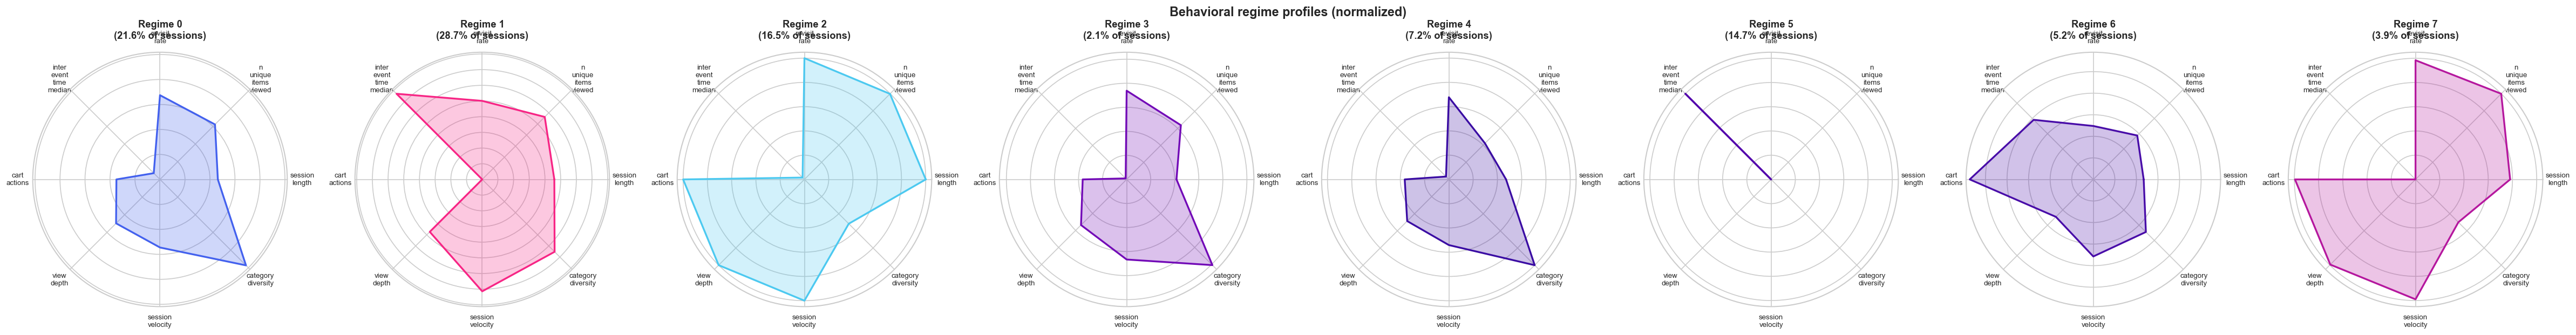

[SAVED] 07_regime_radar.png


In [ ]:
# ── Radar / Spider chart — relative profile per regime ────────────────────────
# Normalize to 0-1 for comparability
profile_norm = profile_raw[CFG["features"]].copy()
profile_norm = (profile_norm - profile_norm.min()) / (
    profile_norm.max() - profile_norm.min() + 1e-9
)

features_radar = CFG["features"]
n_feat = len(features_radar)
angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(
    1, BEST_K, figsize=(5 * BEST_K, 5),
    subplot_kw=dict(polar=True)
)
if BEST_K == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    values = profile_norm.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=PALETTE[i], lw=2)
    ax.fill(angles, values, color=PALETTE[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [f.replace("_", "\n") for f in features_radar], fontsize=8
    )
    ax.set_yticklabels([])
    pct = profile_raw.iloc[i]["pct"]
    ax.set_title(f"Regime {i}\n({pct:.1f}% of sessions)",
                 fontsize=11, fontweight="bold", pad=15)

fig.suptitle("Behavioral regime profiles (normalized)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/07_regime_radar.png", bbox_inches="tight")
plt.show()
print("[SAVED] 07_regime_radar.png")

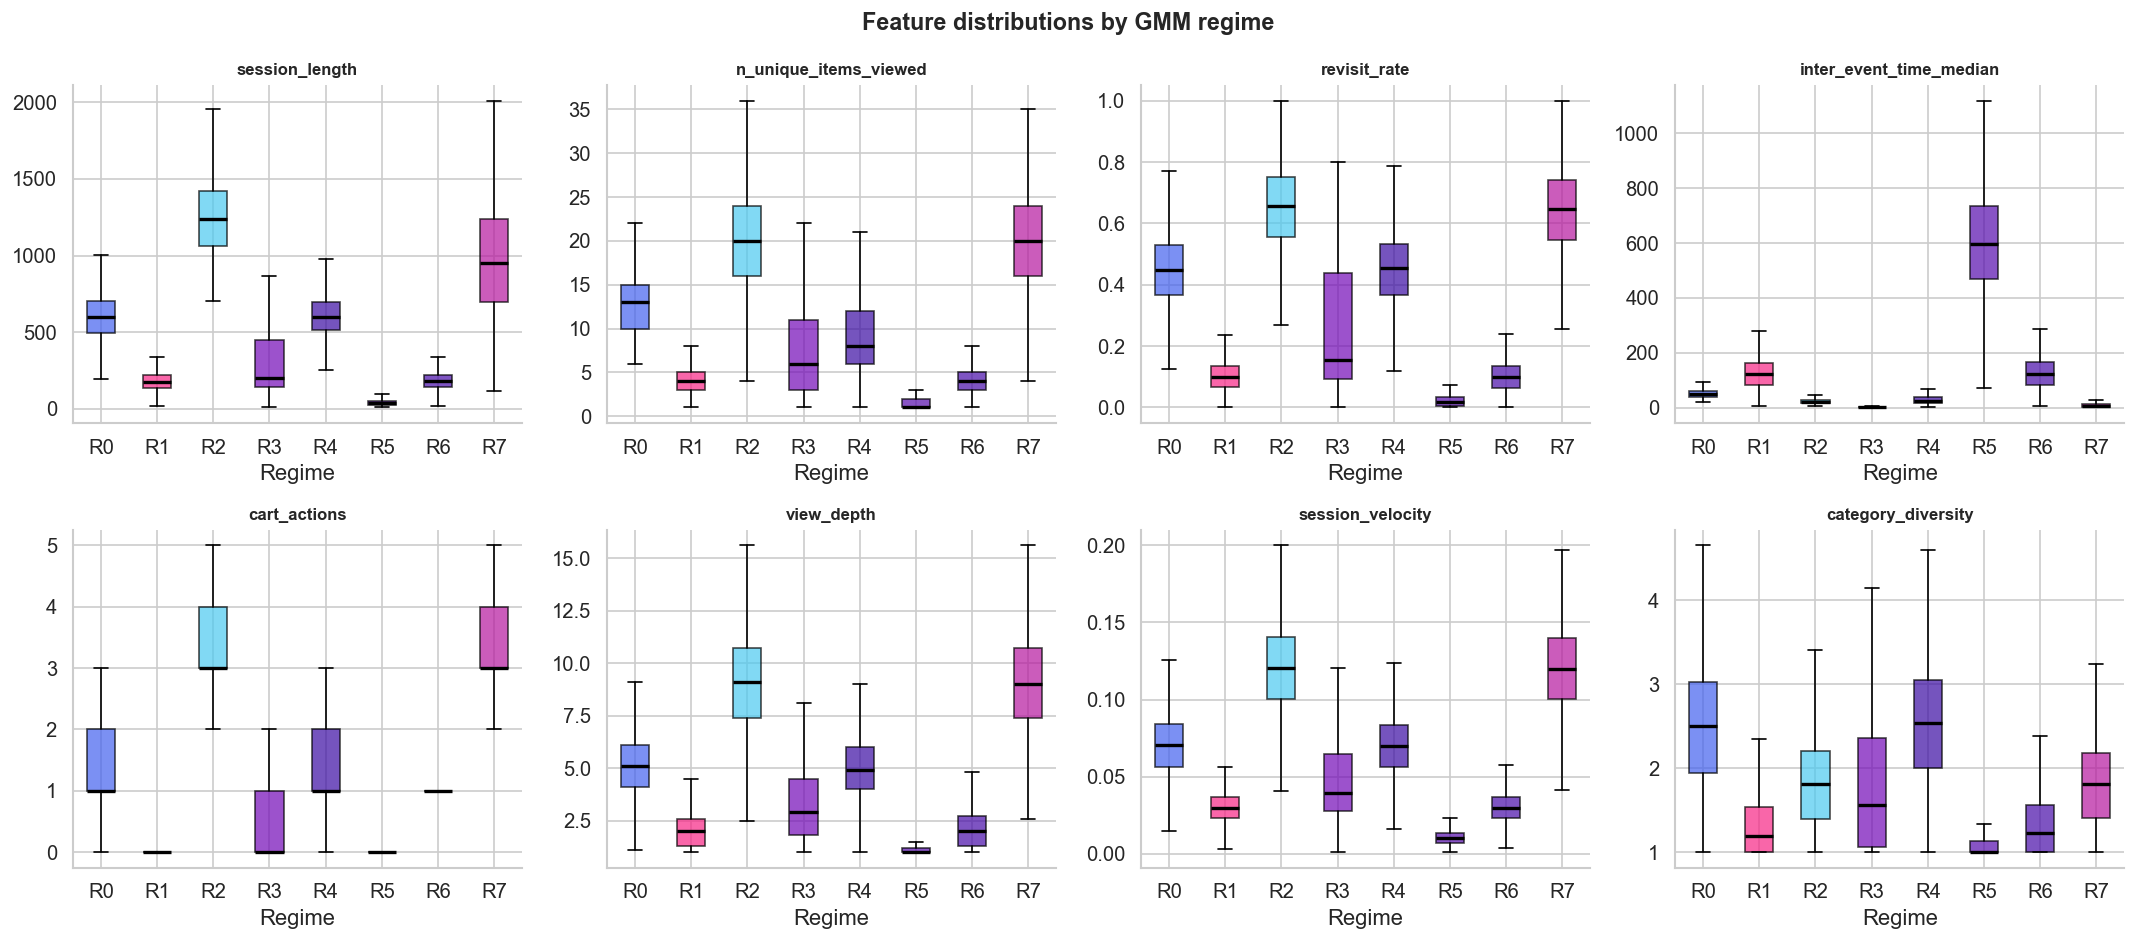

[SAVED] 08_feature_boxplots.png


In [ ]:
# ── Feature boxplots by regime ─────────────────────────────────────────────────
n_features = len(CFG["features"])
n_cols = 4
n_rows = -(-n_features // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(CFG["features"]):
    ax = axes[i]
    data_by_regime = [
        df_sessions.loc[df_sessions["gmm_regime"] == k, feat].values
        for k in range(BEST_K)
    ]
    bp = ax.boxplot(
        data_by_regime,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", lw=2),
    )
    for patch, color in zip(bp["boxes"], PALETTE[:BEST_K]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_xticklabels([f"R{k}" for k in range(BEST_K)])
    ax.set_xlabel("Regime")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature distributions by GMM regime",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/08_feature_boxplots.png", bbox_inches="tight")
plt.show()
print("[SAVED] 08_feature_boxplots.png")

In [ ]:
# ── GMM component parameters: means + covariances ────────────────────────────
print("GMM Component Means (scaled feature space):")
means_df = pd.DataFrame(
    final_gmm.means_,
    columns=CFG["features"],
    index=[f"Regime {k}" for k in range(BEST_K)]
)
display(means_df.round(3))

print("\nGMM Component Weights (mixture proportions):")
for k, w in enumerate(final_gmm.weights_):
    print(f"  Regime {k}: {w:.3f} ({100*w:.1f}%)")

GMM Component Means (scaled feature space):


,session_length,n_unique_items_viewed,revisit_rate,inter_event_time_median,cart_actions,view_depth,session_velocity,category_diversity
Regime 0,0.404,0.401,0.536,-0.135,0.608,0.383,0.431,0.843
Regime 1,-0.369,-0.414,-0.241,0.344,0.000,-0.270,-0.232,-0.167
Regime 2,0.871,0.692,0.995,-0.634,1.745,1.248,1.257,0.275
Regime 3,-0.260,-0.112,0.116,-1.652,0.328,-0.000,0.062,0.277
Regime 4,0.417,0.151,0.534,-0.467,0.632,0.367,0.428,0.869
Regime 5,-1.326,-0.938,-0.418,1.344,0.000,-0.473,-0.555,-0.371
Regime 6,-0.362,-0.406,-0.243,0.345,0.500,-0.262,-0.232,-0.156
Regime 7,0.716,0.704,0.973,-1.168,1.731,1.241,1.231,0.252



GMM Component Weights (mixture proportions):
  Regime 0: 0.201 (20.1%)
  Regime 1: 0.287 (28.7%)
  Regime 2: 0.156 (15.6%)
  Regime 3: 0.022 (2.2%)
  Regime 4: 0.086 (8.6%)
  Regime 5: 0.147 (14.7%)
  Regime 6: 0.052 (5.2%)
  Regime 7: 0.049 (4.9%)


In [ ]:
# ── Regime labeling guide ─────────────────────────────────────────────────────
# Auto-generate descriptive labels based on feature means
# You should review and override these manually after inspecting the profiles.

def auto_label_regimes(profile: pd.DataFrame, features: list) -> dict:
    """
    Heuristically assign descriptive labels to regimes based on feature ranks.
    This is a starting point — always review manually.
    """
    labels = {}
    cart_col = "cart_actions" if "cart_actions" in features else None
    sess_col = "session_length" if "session_length" in features else None
    revisit_col = "revisit_rate" if "revisit_rate" in features else None

    for k in profile.index:
        row = profile.loc[k, features]
        rank = row.rank(pct=True)  # percentile rank within regime

        cart_pct  = rank[cart_col]    if cart_col    else 0.5
        sess_pct  = rank[sess_col]    if sess_col    else 0.5
        rev_pct   = rank[revisit_col] if revisit_col else 0.5

        if cart_pct > 0.7 and sess_pct > 0.6:
            label = "Purchase-intent"
        elif rev_pct > 0.7 and cart_pct > 0.4:
            label = "Comparison shopper"
        elif sess_pct < 0.3 and cart_pct < 0.3:
            label = "Cold-start / churn"
        else:
            label = "Casual browser"
        labels[k] = label

    return labels


# Use original-scale profile for labeling
auto_labels = auto_label_regimes(profile_raw, CFG["features"])

print("Auto-generated regime labels (review and override as needed):")
for k, label in auto_labels.items():
    print(f"  Regime {k} → '{label}'")

# ── OVERRIDE HERE if needed after inspection ──────────────────────────────────
# REGIME_LABELS = {
#     0: "Casual browser",
#     1: "Comparison shopper",
#     2: "Purchase-intent",
#     3: "Cold-start / churn",
# }
REGIME_LABELS = auto_labels

df_sessions["regime_label"] = df_sessions["gmm_regime"].map(REGIME_LABELS)
print("\nLabel distribution:")
print(df_sessions["regime_label"].value_counts())

Auto-generated regime labels (review and override as needed):
  Regime 0 → 'Casual browser'
  Regime 1 → 'Casual browser'
  Regime 2 → 'Casual browser'
  Regime 3 → 'Casual browser'
  Regime 4 → 'Casual browser'
  Regime 5 → 'Casual browser'
  Regime 6 → 'Casual browser'
  Regime 7 → 'Casual browser'

Label distribution:
regime_label
Casual browser    30000
Name: count, dtype: int64


## 9. Dimensionality Reduction Visualizations (PCA + UMAP)

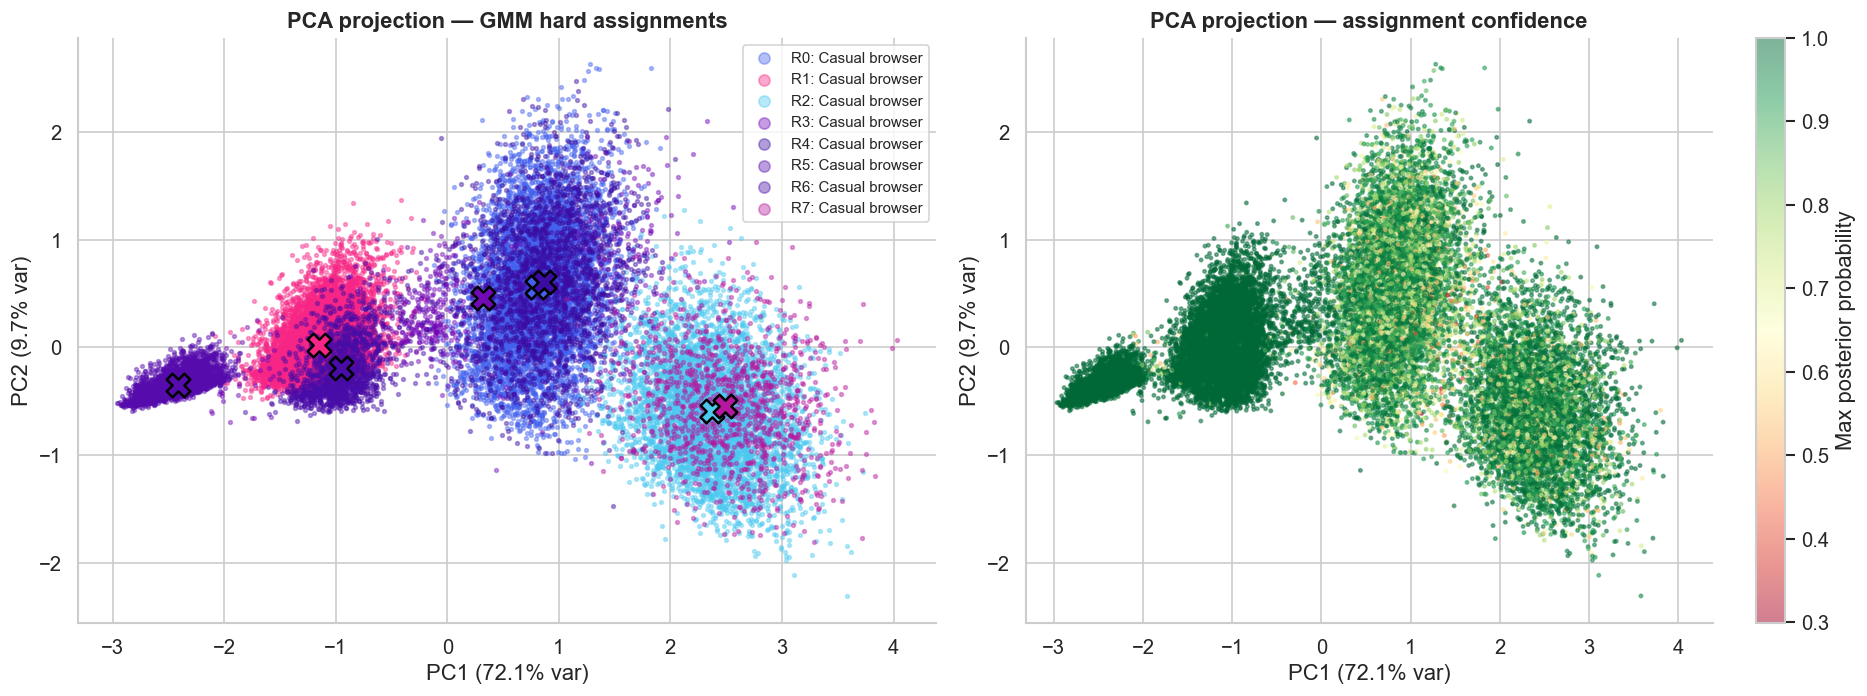

[SAVED] 09_pca_visualization.png
PCA explained variance: PC1=0.721, PC2=0.097


In [ ]:
# ── PCA 2D visualization ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

# Sample for plotting speed on large datasets
plot_n = min(30_000, len(df_sessions))
sample_idx = np.random.choice(len(df_sessions), plot_n, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hard labels
ax = axes[0]
for k in range(BEST_K):
    mask = hard_labels[sample_idx] == k
    ax.scatter(
        X_pca[sample_idx][mask, 0],
        X_pca[sample_idx][mask, 1],
        s=5, alpha=0.4, color=PALETTE[k],
        label=f"R{k}: {REGIME_LABELS.get(k, k)}"
    )
    # Plot GMM means
    mean_2d = pca.transform(final_gmm.means_[k:k+1])
    ax.scatter(mean_2d[0, 0], mean_2d[0, 1], s=200, marker="X",
               color=PALETTE[k], edgecolor="black", zorder=10, lw=1.5)

ax.set_title("PCA projection — GMM hard assignments", fontweight="bold")
ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
ax.legend(markerscale=3, fontsize=9)

# Confidence
ax = axes[1]
sc = ax.scatter(
    X_pca[sample_idx, 0], X_pca[sample_idx, 1],
    c=soft_probs[sample_idx].max(axis=1),
    cmap="RdYlGn", s=4, alpha=0.5, vmin=0.3, vmax=1.0
)
plt.colorbar(sc, ax=ax, label="Max posterior probability")
ax.set_title("PCA projection — assignment confidence", fontweight="bold")
ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/09_pca_visualization.png", bbox_inches="tight")
plt.show()
print("[SAVED] 09_pca_visualization.png")
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}")

In [ ]:
# ── UMAP visualization (optional, better separation) ─────────────────────────
if UMAP_AVAILABLE:
    print("Running UMAP... (this may take ~1-3 min on large datasets)")
    umap_sample = min(50_000, len(df_sessions))
    umap_idx = np.random.choice(len(df_sessions), umap_sample, replace=False)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=RANDOM_STATE,
        verbose=False
    )
    X_umap = reducer.fit_transform(X[umap_idx])

    fig, ax = plt.subplots(figsize=(9, 7))
    for k in range(BEST_K):
        mask = hard_labels[umap_idx] == k
        ax.scatter(
            X_umap[mask, 0], X_umap[mask, 1],
            s=5, alpha=0.4, color=PALETTE[k],
            label=f"R{k}: {REGIME_LABELS.get(k, k)}"
        )
    ax.set_title("UMAP projection — GMM regime assignments",
                 fontweight="bold", fontsize=12)
    ax.set_xlabel("UMAP dim 1")
    ax.set_ylabel("UMAP dim 2")
    ax.legend(markerscale=4, fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/10_umap_visualization.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] 10_umap_visualization.png")
else:
    print("[SKIPPED] UMAP not available. Install with: pip install umap-learn")

NameError: name 'UMAP_AVAILABLE' is not defined

## 10. Stability Validation
> Validates that GMM regime assignments are reproducible across bootstrap samples. A good model should assign >80% of sessions to the same regime across runs.

In [ ]:
from sklearn.metrics import adjusted_rand_score

def bootstrap_stability(
    X: np.ndarray,
    k: int,
    cov_type: str,
    n_bootstrap: int,
    sample_frac: float,
    random_state: int,
) -> dict:
    """
    Assess GMM stability via bootstrap:
    - Fit GMM on a subsample
    - Predict labels on the full dataset (out-of-bag)
    - Compute Adjusted Rand Index (ARI) between bootstrap runs

    Returns dict with mean/std ARI and per-run details.
    """
    rng = np.random.default_rng(random_state)
    n = len(X)
    n_sample = int(n * sample_frac)
    all_labels = []

    for i in tqdm(range(n_bootstrap), desc="Bootstrap stability runs"):
        idx = rng.choice(n, n_sample, replace=True)
        gmm_b = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            n_init=5,
            max_iter=300,
            random_state=int(rng.integers(0, 10_000)),
        )
        gmm_b.fit(X[idx])
        all_labels.append(gmm_b.predict(X))  # predict on full dataset

    # Compute pairwise ARI between bootstrap runs
    ari_scores = []
    for i in range(n_bootstrap):
        for j in range(i + 1, n_bootstrap):
            ari_scores.append(adjusted_rand_score(all_labels[i], all_labels[j]))

    return {
        "mean_ari": np.mean(ari_scores),
        "std_ari":  np.std(ari_scores),
        "min_ari":  np.min(ari_scores),
        "all_ari":  ari_scores,
    }


print(f"Running bootstrap stability validation ({CFG['bootstrap_n']} runs)...")
stability = bootstrap_stability(
    X=X,
    k=BEST_K,
    cov_type=CFG["final_cov_type"],
    n_bootstrap=CFG["bootstrap_n"],
    sample_frac=CFG["bootstrap_sample_frac"],
    random_state=RANDOM_STATE,
)

print(f"\n── Stability Results ────────────────────────────────")
print(f"  Mean ARI  : {stability['mean_ari']:.4f}")
print(f"  Std  ARI  : {stability['std_ari']:.4f}")
print(f"  Min  ARI  : {stability['min_ari']:.4f}")

if stability["mean_ari"] > 0.85:
    print("  ✅ HIGH stability — regime structure is reproducible")
elif stability["mean_ari"] > 0.60:
    print("  ⚠️  MODERATE stability — consider reviewing K or features")
else:
    print("  ❌ LOW stability — regime structure is unstable; revisit K or data")

Running bootstrap stability validation (30 runs)...


Bootstrap stability runs:   0%|          | 0/30 [00:00<?, ?it/s]


── Stability Results ────────────────────────────────
  Mean ARI  : 0.8581
  Std  ARI  : 0.0778
  Min  ARI  : 0.5659
  ✅ HIGH stability — regime structure is reproducible


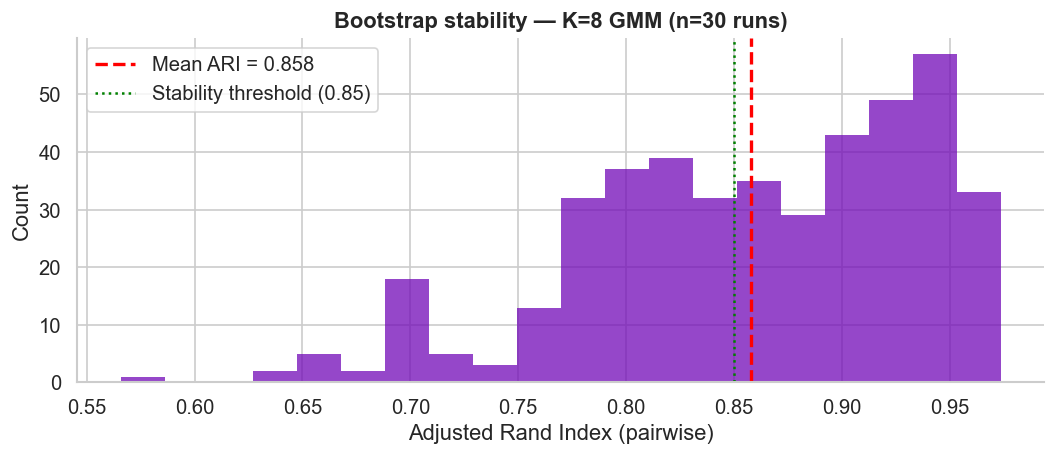

[SAVED] 11_stability_validation.png


In [ ]:
# ── Plot stability distribution ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(stability["all_ari"], bins=20, color=PALETTE[3], alpha=0.75, edgecolor="none")
ax.axvline(stability["mean_ari"], color="red", lw=2, ls="--",
           label=f"Mean ARI = {stability['mean_ari']:.3f}")
ax.axvline(0.85, color="green", lw=1.5, ls=":", label="Stability threshold (0.85)")
ax.set_xlabel("Adjusted Rand Index (pairwise)")
ax.set_ylabel("Count")
ax.set_title(f"Bootstrap stability — K={BEST_K} GMM (n={CFG['bootstrap_n']} runs)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/11_stability_validation.png", bbox_inches="tight")
plt.show()
print("[SAVED] 11_stability_validation.png")

## 11. Saving Outputs & Summary

In [ ]:
# ── Save labelled dataset ─────────────────────────────────────────────────────
output_cols = (
    ["user_id", "session_id", "gmm_regime", "regime_label", "max_posterior"]
    + [f"prob_regime_{k}" for k in range(BEST_K)]
    + CFG["features"]
)
if HAS_TRUE_LABELS:
    output_cols.insert(3, "true_regime")

df_output = df_sessions[[c for c in output_cols if c in df_sessions.columns]]
df_output.to_parquet(f"{CFG['output_dir']}/sessions_with_gmm_labels.parquet", index=False)
df_output.to_csv(f"{CFG['output_dir']}/sessions_with_gmm_labels.csv", index=False)
print(f"[SAVED] sessions_with_gmm_labels (.parquet + .csv) — {len(df_output):,} rows")

[SAVED] sessions_with_gmm_labels (.parquet + .csv) — 30,000 rows


Recovery metrics (vs. true simulated regimes):
  Adjusted Rand Index         : 0.7530  (1.0 = perfect)
  Normalized Mutual Info      : 0.8231  (1.0 = perfect)


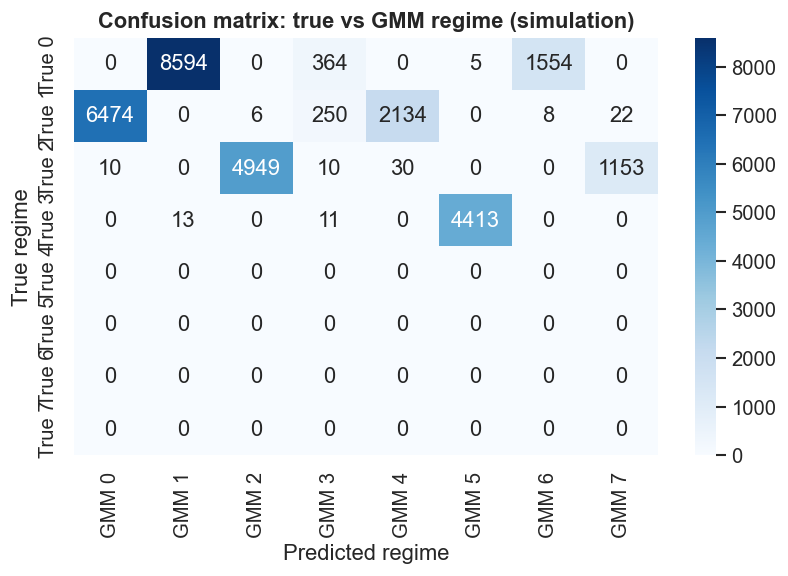

[SAVED] 12_confusion_matrix.png


In [ ]:
# ── Validation against true labels (simulation only) ─────────────────────────
if HAS_TRUE_LABELS:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    ari  = adjusted_rand_score(df_sessions["true_regime"], df_sessions["gmm_regime"])
    nmi  = normalized_mutual_info_score(df_sessions["true_regime"], df_sessions["gmm_regime"])
    print(f"Recovery metrics (vs. true simulated regimes):")
    print(f"  Adjusted Rand Index         : {ari:.4f}  (1.0 = perfect)")
    print(f"  Normalized Mutual Info      : {nmi:.4f}  (1.0 = perfect)")

    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(df_sessions["true_regime"], df_sessions["gmm_regime"])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=[f"GMM {k}" for k in range(BEST_K)],
                yticklabels=[f"True {k}" for k in range(len(cm))])
    ax.set_title("Confusion matrix: true vs GMM regime (simulation)", fontweight="bold")
    ax.set_xlabel("Predicted regime")
    ax.set_ylabel("True regime")
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/12_confusion_matrix.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] 12_confusion_matrix.png")

In [ ]:
# ── Save complete run summary (JSON) ─────────────────────────────────────────
summary = {
    "run_timestamp":       datetime.now().isoformat(),
    "n_sessions":          int(len(df_sessions)),
    "n_users":             int(df_sessions["user_id"].nunique()),
    "features_used":       CFG["features"],
    "scaler":              CFG["scaler"],
    "log_transformed":     CFG["log_transform_cols"],
    "best_k":              BEST_K,
    "covariance_type":     CFG["final_cov_type"],
    "bic":                 float(final_gmm.bic(X)),
    "aic":                 float(final_gmm.aic(X)),
    "converged":           bool(final_gmm.converged_),
    "stability_mean_ari":  float(stability["mean_ari"]),
    "stability_std_ari":   float(stability["std_ari"]),
    "regime_labels":       {str(k): v for k, v in REGIME_LABELS.items()},
    "regime_sizes":        {
        str(k): int(v)
        for k, v in df_sessions["gmm_regime"].value_counts().sort_index().items()
    },
    "high_confidence_pct": float((df_sessions["max_posterior"] > 0.8).mean()),
}

if HAS_TRUE_LABELS:
    summary["recovery_ari"] = float(ari)
    summary["recovery_nmi"] = float(nmi)

with open(f"{CFG['output_dir']}/run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("[SAVED] run_summary.json")
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
for k, v in summary.items():
    if k not in ("features_used", "log_transformed"):
        print(f"  {k:35s}: {v}")
print("=" * 60)
print(f"\nAll outputs saved to: ./{CFG['output_dir']}/")

[SAVED] run_summary.json

FINAL SUMMARY
  run_timestamp                      : 2026-03-21T11:23:41.306777
  n_sessions                         : 30000
  n_users                            : 4985
  scaler                             : robust
  best_k                             : 8
  covariance_type                    : full
  bic                                : -59181.575336930444
  aic                                : -62164.48934210175
  converged                          : True
  stability_mean_ari                 : 0.8580619310530339
  stability_std_ari                  : 0.07782635200880221
  regime_labels                      : {'0': 'Casual browser', '1': 'Casual browser', '2': 'Casual browser', '3': 'Casual browser', '4': 'Casual browser', '5': 'Casual browser', '6': 'Casual browser', '7': 'Casual browser'}
  regime_sizes                       : {'0': 6484, '1': 8607, '2': 4955, '3': 635, '4': 2164, '5': 4418, '6': 1562, '7': 1175}
  high_confidence_pct                : 0.8979

---
## Next Steps → HMM (Main Model)

This GMM notebook establishes the **static baseline**. Key findings to carry forward:

| Finding | What to compare in HMM |
|---|---|
| GMM identifies K behavioral segments | HMM should find similar K states |
| GMM ignores temporal ordering | HMM models state transitions explicitly |
| GMM gives soft cluster memberships | HMM gives posterior state probabilities + Viterbi path |
| Stability ARI from bootstrap | Compare to HMM stability on same bootstrap draws |
| Regime profiles (feature means) | Compare mean vectors: similar structure = consistent regimes |

**Research Question 2** — *How do short-term session dynamics compare to long-term preferences?* — is answered by comparing users whose GMM regime is stable vs. those whose HMM state sequence is highly volatile.

---
*End of GMM baseline notebook*